# Классификация текстов с использованием Наивного Байесовского Классификатора

## Задание 1 (1 балл)

Откройте данные. Узнайте, сколько в них спам- и не спам-писем. Визуализируйте полученные соотношение подходящим образом.

In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv('spam_or_not_spam.csv')
data.head()

,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0


In [3]:
count = data['label'].value_counts() / data.shape[0] * 100
count: pd.DataFrame = count.reset_index()
print('Spam:', round(count[count['label'] == 1]['count'].iloc[0], 2))
print('Ham:', round(count[count['label'] == 0]['count'].iloc[0], 2))

Spam: 16.67
Ham: 83.33


In [4]:
spam = data[data['label'] == 1]['label'].count()
ham = data[data['label'] == 0]['label'].count()
print('Spam:', spam)
print('Ham:', ham)

Spam: 500
Ham: 2500


<Axes: >

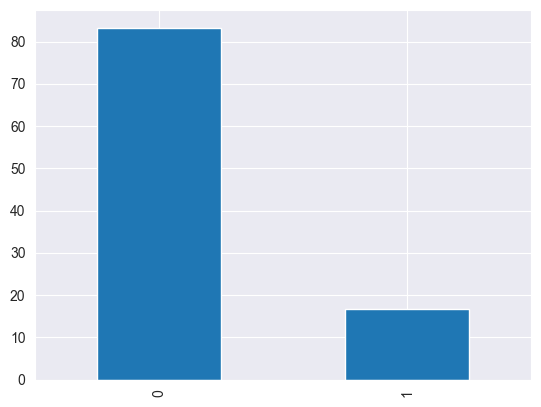

In [5]:
count['count'].plot.bar()

## Задание 2 (2 балла)

Вам необходимо предобработать ваши данные и перевести их в векторный вид. Подгрузим необходимый модуль:

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

Замените в данных все пустые строки и строки, состоящие из пробелов, на пропуски (NaN). После этого удалите из данных все строки, в которых наблюдаются пропущенные значения.

In [7]:
data['email'] = data['email'].apply(lambda x: x.strip() if isinstance(x, str) else x)
data = data.replace('', np.nan)
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2997 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   email   2997 non-null   object
 1   label   2997 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 70.2+ KB


Переводим данные в векторный вид:

In [8]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(data["email"])

Определите, сколько теперь признаков в нашем наборе данных:

In [9]:
X.shape[1]

34116

## Задание 3 (2 балла)

Определите целевую переменную и признаки:

In [10]:
y = data['label']

Разделите выборку на обучающую и тестовую, используя стратифицированное разбиение (параметр `stratify` установите в значение вектора ответов y) размер тестовой выборки (`test_size`) возьмите как 0.25, параметр `random_state` определите со значением 42:

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, stratify=y, random_state=42)

Рассчитайте среднее значение целевой переменной по тестовой выборке:

In [12]:
round(y_test.mean(), 3)

np.float64(0.165)

## Задание 4 (3 балла)

Определите и обучите подходящий алгоритм с параметром alpha = 0.01

In [13]:
from sklearn.naive_bayes import ComplementNB, MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score

alpha=0.01
com_model = ComplementNB(alpha=alpha)
mul_model = MultinomialNB(alpha=alpha)

com_model.fit(X_train, y_train)
mul_model.fit(X_train, y_train)

MultinomialNB(alpha=0.01)

In [14]:
y_com_pred = com_model.predict(X_test)
y_mul_pred = mul_model.predict(X_test)

Оцените результат с точки зрения всех известных вам метрик (не менее трёх):

In [15]:
print('ComplementNB accuracy:', accuracy_score(y_com_pred, y_test))
print('ComplementNB precision:', precision_score(y_com_pred, y_test, pos_label=0))
print('ComplementNB recall:', recall_score(y_com_pred, y_test, pos_label=0), '\n')
print('MultinomialNB accuracy:', accuracy_score(y_mul_pred, y_test))
print('MultinomialNB precision:', precision_score(y_mul_pred, y_test, pos_label=0))
print('MultinomialNB recall:', recall_score(y_mul_pred, y_test, pos_label=0))

ComplementNB accuracy: 0.988
ComplementNB precision: 1.0
ComplementNB recall: 0.9858267716535433 

MultinomialNB accuracy: 0.9866666666666667
MultinomialNB precision: 1.0
MultinomialNB recall: 0.9842767295597484


Нарисуйте ROC-кривую:

In [16]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_com_pred)
auc_value = roc_auc_score(y_test, y_com_pred)

print("AUC =", auc_value)

AUC = 0.9637096774193548


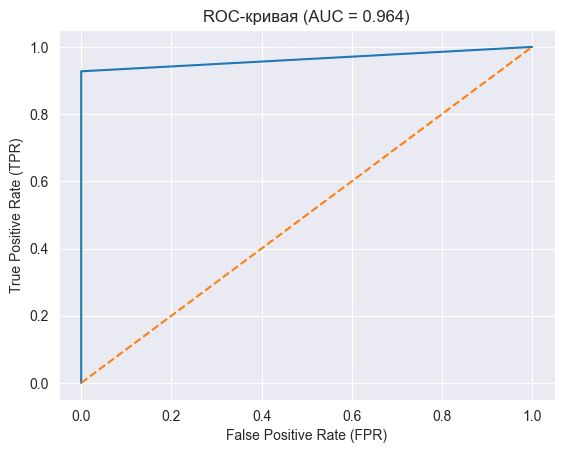

In [17]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-кривая (AUC = {:.3f})'.format(auc_value))
plt.grid(True)
plt.show()

## Задание 5 (3 балла)

Переберите несколько значений alpha с помощью кросс-валидации. Оцените, зависит ли от этого параметра качество классификации.

In [30]:
from sklearn.model_selection import cross_val_score

alphas = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]

results = []
for alpha in alphas:
    clf = ComplementNB(alpha=alpha)
    scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
    results.append({
        'alpha': alpha,
        'mean_accuracy': scores.mean()
    })

df_results = pd.DataFrame(results)
print(df_results)

   alpha  mean_accuracy
0   0.01       0.982647
1   0.10       0.982987
2   0.50       0.981650
3   1.00       0.981648
4   5.00       0.952275
5  10.00       0.897218


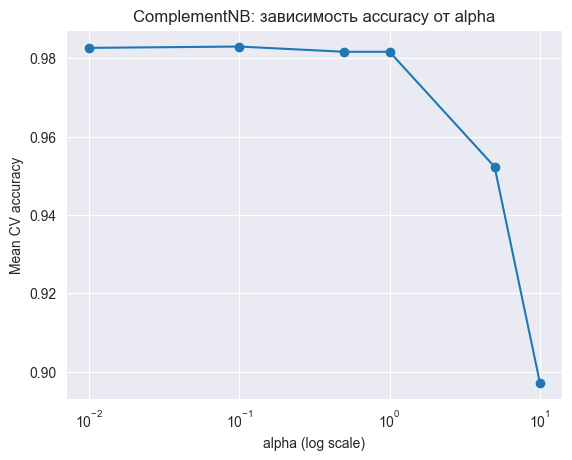

In [29]:
plt.plot(df_results['alpha'], df_results['mean_accuracy'], marker='o')
plt.xscale('log')
plt.xlabel('alpha (log scale)')
plt.ylabel('Mean CV accuracy')
plt.title('ComplementNB: зависимость accuracy от alpha')
plt.grid(True)
plt.show()